In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections.abc import Callable
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from scipy.linalg import eig, eigvals

In [2]:
class TickProperties():
    
    major_xtick_step = 5,
    minor_xtick_step = 1
    major_ytick_step = 5
    minor_ytick_step = 1
    STRIP_OF_ZEROS_X = False
    STRIP_OF_ZEROS_Y = False

    def __init__(self,\
    xtick_step_major = 5,\
    xtick_step_minor = 1,\
    ytick_step_major = 5,\
    ytick_step_minor = 1,\
    SZX = False,\
    SZY = False):
        self.major_xtick_step = xtick_step_major
        self.minor_xtick_step = xtick_step_minor
        self.major_ytick_step = ytick_step_major
        self.minor_ytick_step = ytick_step_minor
        self.STRIP_OF_ZEROS_X = SZX
        self.STRIP_OF_ZEROS_Y = SZY

class Format():
    numb_xticks = None
    numb_yticks = None
    custom_func_x = None
    custom_func_y = None
    x_scale = None
    y_scale = None
    x_precion = "{:.2f}"
    y_precion = "{:.2f}"
    def __init__(self,numb_xticks=None,numb_yticks=None,custom_funx=None,custom_funy=None,xscale=None,yscale=None,xprec="{:.2f}",yprec="{:.2f}"):
        self.numb_xticks =numb_xticks
        self.numb_yticks = numb_yticks
        self.custom_func_x = custom_funx
        self.custom_func_y = custom_funy
        self.x_precion=xprec
        self.y_precion = yprec
        self.x_scale = xscale
        self.y_scale = yscale
    def formatx0(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            # print(x,pos,self.numb_xticks)
            index = int((pos-1)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print(self.x_precion.format(self.x_scale[index]))
            return self.x_precion.format(self.x_scale[index])
        except:
            return self.x_precion.format(self.x_scale[-1])
    def formatx1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            # print(pos)
            index = int((pos)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print()
            return self.x_precion.format(self.x_scale[index])
        except:
            return self.x_precion.format(self.x_scale[-1])
    
    def formaty1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))

            index = int((pos-1)*self.y_scale.shape[0]//self.numb_yticks)
            # print(index)
            # print()
            return self.y_precion.format(self.y_scale[index])
        except:
            return self.y_precion.format(self.y_scale[-1])
        
    def formaty(self,x,pos):
        try:
            return self.y_precion.format(self.y_scale[int(x)])
        except:
            return ""

class Setup_Fig():
    DEFAULT_HEAT_EXTEND = (-0.5,39.5,29.5,-0.5)
    xlim = None
    ylim = None
    tickprop = TickProperties()
    formatter = Format()
    cm = 1/2.54 
    fig_width = 12*cm
    fig_height = 4.8/6.4*12*cm
    name_of_plot = None
    xax_share = None
    yax_share = None
    joined= None
    def __init__(self,name_of_plot = "sign_of_ev1.pdf",xlim=None,ylim=None,tickp=TickProperties(),formater=Format(),xax_share = False, yax_share = False, joined= False,fig_width = 12*cm,fig_height = 4.8/6.4*12*cm):
        self.xlim=xlim
        self.ylim = ylim   
        self.tickprop =tickp       
        self.formatter = formater
        self.name_of_plot = name_of_plot
        self.xax_share = xax_share 
        self.yax_share = yax_share 
        self.joined = joined
        self.fig_height = fig_height
        self.fig_width = fig_width


    
    plt.rcParams["lines.markersize"]=0.7
    plt.rcParams["axes.unicode_minus"]=True
    plt.rcParams["font.size"]=10
    plt.rcParams["text.usetex"]=True
    plt.rcParams["font.serif"]="Computer Modern Serif"
# ax.scatter(A,root,color='0')
    



    def return_fig(self,shape=(1,1),dots_per_inch=400,heightratio=None):
        if heightratio:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=self.xax_share,sharey=self.yax_share,height_ratios=heightratio)
        else:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=self.xax_share,sharey=self.yax_share)
        # trash, xw, yw, trash=self.DEFAULT_HEAT_EXTEND# im.get_extent()
        # self.formatter.numb_xticks = xw//self.tickprop.major_xtick_step
        # self.formatter.numb_yticks = yw//self.tickprop.major_ytick_step
        return fig, ax
    
    def return_gridspec(self,shape=(1,1),dots_per_inch=400):
        fig = plt.figure(figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch)
        gs = gridspec.GridSpec(*shape, figure=fig)
        if shape[0]==1 or shape[1]==1:
            num = max(shape)
            axes = np.empty((num),dtype=object)
            for i in range(shape[0]):
                for j in range(shape[1]):
                    axes[i+j] = fig.add_subplot(gs[i,j])
        else:
            axes = np.empty(shape,dtype=object)
            # axes = []
            for i in range(shape[0]):
                for j in range(shape[1]):
                    axes[i,j] =  fig.add_subplot(gs[i,j])
                    # axes.append(fig.add_subplot(gs[i,j]))
                # axes[-1].set_aspect('auto')
        return fig, axes

        
    def format_ax(self,current_ax,shape,tickprop=None,j=0,bottom=True,set_ticks=True):
        trash, xw, yw, trash=self.DEFAULT_HEAT_EXTEND# im.get_extent()
        self.formatter.numb_xticks = xw//self.tickprop.major_xtick_step
        self.formatter.numb_yticks = yw//self.tickprop.major_ytick_step
        pos= 'outer_left'
        current_ax.set_aspect('auto')
        if shape[1]>1:
                if j==0:
                    pos= 'outer_left'
                elif j<shape[1]-1:
                    pos = 'middle'
                elif j==shape[1]-1:
                    pos = 'outer_right'
                


        # axlimits have to be adapted
        try:
            current_ax.set_xlim(*self.xlim)
        except:
            pass
        try:
            current_ax.set_ylim(*self.ylim)
        except:
            pass    
    
        if set_ticks:
            if tickprop.STRIP_OF_ZEROS_X:
                current_ax.xaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formatx0))
            current_ax.yaxis.set_major_locator(ticker.MultipleLocator(tickprop.major_ytick_step))
            current_ax.yaxis.set_minor_locator(ticker.MultipleLocator(tickprop.minor_ytick_step))
            current_ax.xaxis.set_major_locator(ticker.MultipleLocator(tickprop.major_xtick_step))
            current_ax.xaxis.set_minor_locator(ticker.MultipleLocator(tickprop.minor_xtick_step))

            if tickprop.STRIP_OF_ZEROS_Y:
                current_ax.yaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formaty1))  

        if self.joined:
            if not bottom:
                current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=False)
            else:
                current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
                
            if pos=='outer_left':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)
            elif pos=='middle':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=False)
            elif pos=='outer_right':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelright=True,labelleft=False)
                # current_ax.set_xlabel(r'$\Gamma \tilde{A}$')
                # current_ax.set_ylabel(r'$\tilde{y}$',rotation=0)
        else:
            current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
            
            current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)   


        current_ax.tick_params(axis='both',which='major',length=4.5)
        plt.setp(current_ax.yaxis.get_majorticklabels(),va='center')
        
        return current_ax

In [3]:
def sort_eigenvalues(eigenvalues: np.ndarray,eigenvectors: np.ndarray) -> np.ndarray:
    """Sort eigenvalues in ascending order."""
    # eigenvectors *= np.conjugate(eigenvectors[0, :])/np.absolute(eigenvectors[0,:])#np.array([np.absolute(eigenvectors[0,i]) for i in range(eigenvectors.shape[1])]) # Normalize the eigenvectors
    comb = np.column_stack((eigenvalues.T, eigenvectors.T))
    # return comb
    # sorted_comb = sorted(comb, key=lambda x: np.abs(x[0]))
    sorted_comb = sorted(comb, key=lambda x: np.abs(x[0]))
    return np.array(sorted_comb)

In [4]:
# interaction and lattice definition

# BASE_A = np.zeros(3)
# BASE_B = np.array([1/np.sqrt(3),0,0])
# LATTICE_VECTOR_2 = np.array([0,1,0])
# LATTICE_VECTOR_1 = 1/2*np.array([np.sqrt(3),1,0])
# LATTICE_VECTOR_1_ALTERNATIVE = np.sqrt(3)*np.array([1,0,0])

# REZI_2 = 2*np.pi/np.sqrt(3)*np.array([-1,np.sqrt(3),0])   
# REZI_1 = 4*np.pi/np.sqrt(3)*np.array([1,0,0])
# # alternative can't be used, gives wrong results
# REZI_1_ALTERNATIVE = 2*np.pi/np.sqrt(3)*np.array([1,0,0])
# REZI_2_ALTERNATIVE = 2*np.pi*np.array([0,1,0])


def bare_interaction(Delta_R_vec: np.ndarray, i: int, j: int, interaction_radius: float) -> float:
    """Calculate the bare interaction between two dipoles."""
    # Delta_R_vec /= 5
    Del_R = np.linalg.norm(Delta_R_vec)
    # if Del_R > np.sqrt(3)+0.01:
    # if Del_R > 1.01:
    if Del_R >interaction_radius+0.01:
        return 0
    potential = 0
    if i == j:
        potential += 3/ Del_R**5
        if i == 2:
            potential += 6/ Del_R**5
    potential -= 15/Del_R**7 *Delta_R_vec[i] * Delta_R_vec[j]
    return potential

def dip_derivative_full(Delta_R_vec: np.ndarray, i: int, j: int, d: np.ndarray,interaction_radius=None) -> float:
    Del_R = np.linalg.norm(Delta_R_vec)

    if Del_R==0:
        return 0
    # elif Del_R > interaction_radius + 0.01:
    #     return 0
    potential = 0

    if i == j:
        potential += 3/ Del_R**5-15*np.dot(d,Delta_R_vec)**2/Del_R**7
    potential += 6/ Del_R**5*d[i]*d[j]
    potential -= 30*(d[i]*Delta_R_vec[j]+d[j]*Delta_R_vec[i])*np.dot(d,Delta_R_vec)/Del_R**7
    potential -= 15*Delta_R_vec[i]*Delta_R_vec[j]*(1/Del_R**7-7*np.dot(d,Delta_R_vec)**2/Del_R**9)
    # return Del_R
    return potential

def dip_dip(r_vec,d):
    r = np.linalg.norm(r_vec)
    if r==0:
        return 0
    potential = 1/r**3 * (1- 3*(np.dot(d,r_vec)/r)**2)
    return potential


def dipole_trap_onsite(i: int, j:int) -> float:
    if i==j:
        return 1
    else:
        return 0

def max_phi(r):
    return min(np.arccos((np.sqrt(1+2*r**2)-1)/2/r),np.arccos((r-1)/r))

def d_1(a,e):
    d = 0.9
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    A = 12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9)
    B = 15*(a*e/r1**7-e/r2**7)
    res =  B**2*(1-d**2)/(A**2*d**2+B**2*(1-d**2))
    return np.array([np.sqrt(res),np.where(A*B>=0,1,-1)*np.sqrt(1-res)])

def interaction_rotated(DelR,i,j,interaction_radius,d1):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    d2 =0.9
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0

    if i==j:
        B = -3/r**5+15*DelR[i]**2/r**7
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        return A*d1[0]*d2 - B*d1[1]*np.sqrt(1-d2**2)
    else:
        A = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        B = 15 *DelR[0]*DelR[1]/r**7
        return d1[0]*d2*A-B*d1[1]*np.sqrt(1-d2**2)
    

def phi_1(a,e):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    B = (12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9))*(-1)
    A = 45*(a*e/r1**7-e/r2**7)-7*15*(a**3*e/r1**9-e/r2**9)
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res

def d_plane(a,e):
    d = 0.7
    phi = phi_1(a,e)
    return d*np.array([np.cos(phi),np.sin(phi)])

def phi_2(r,phi):
    B  = (-1)*(24/r**5-7*15*np.cos(phi)**2*np.sin(phi)**2/r**5)
    A = 45*np.cos(phi)*np.sin(phi)/r**5-7*15*np.cos(phi)**3*np.sin(phi)/r**5
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res

def d_plane_2(r,phi):
    d = 0.7
    phi_d = phi_2(r,phi)
    return d*np.array([np.cos(phi_d),np.sin(phi_d)])

def interaction_dipplain(DelR,i,j,interaction_radius,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0
    
    
    if i==j:
        A = -3/r**5+15*(DelR[0]**2+DelR[i]*DelR[0]*2+ DelR[i]**2)/r**7-7*15*DelR[0]**2*DelR[i]**2/r**9
        B = 15*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        if i==0:
            A += 15*2*DelR[0]**2/r**7-6/r**5
            B += 30*DelR[0]*DelR[1]/r**7
        return A*d[0] + B*d[1]
    else:
        B = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]**3*DelR[1]/r**9
        return A*d[0] + B*d[1]  
    
def max_b(h,a):
    return np.sqrt((a-0.011)**2-h**2)

def Vxy_decomp(x,y):
    r = np.sqrt(x**2+y**2)
    A = 24/r**5-7*30*x**2*y**2/r**9
    C = 45*x*y/r**7
    B = -7*15*x**3*y/r**9
    D = -7*15*x*y**3/r**9
    return np.array([A, B, C, D])

def Vxy(DelR,d):
    A, B, C, D = Vxy_decomp(DelR[0],DelR[1])
    return A*d[0]*d[1]+C+B*d[0]**2+D*d[1]**2

def Vaa(DelR,i,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    A = -3/r**5+15*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**7
    B = -6*d[i]**2/r**5+30*(2*d[i]*DelR[i]*(DelR[0]*d[0]+DelR[1]*d[1]))/r**7
    C = 15*(DelR[i]**2/r**7-7*DelR[i]**2*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**9)
    return A+B+C

def interaction_aligned_dip(DelR,i,j,interaction_radius,beta,d):
    r = np.linalg.norm(DelR)
    
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0
    if i==j:
        return Vaa(DelR,i,d)*beta
    else:
        return Vxy(DelR,d)*beta


def d_aligned(b,h,a):
    A, B, C, D = Vxy_decomp(b,h)+Vxy_decomp(b-a,h)
    a = (D-B)**2+A**2
    bi = -(A**2+2*(C+D)*(D-B))
    c = (C+D)**2
    sq = np.sqrt(bi**2-4*a*c)
    ot = -bi
    dx = np.sqrt((ot+sq)/2/a)
    sign = np.where((-(C+D)+(D-B)*dx**2)*A>=0,1,-1)
    return np.array([dx,np.sqrt(1-dx**2)*sign])




   


def full_interaction(d1: np.ndarray,d2: np.ndarray, Delta_R_vec: np.ndarray, i: int, j: int, interaction_radius: float) -> float:
    """Calculate the bare interaction between two dipoles."""
    # Delta_R_vec /= 5
    Del_R = np.linalg.norm(Delta_R_vec)
    # if Del_R > np.sqrt(3)+0.01:
    # if Del_R > 1.01:
    if Del_R >interaction_radius+0.01:
        return 0
    potential = 0
    if i == j:
        potential += 3/ Del_R**5 - (Delta_R_vec[i]+Delta_R_vec[j])**2*d**2*15/ Del_R**7
        
    potential += -15/Del_R**7 *Delta_R_vec[i] * Delta_R_vec[j] + 6*d**2/ Del_R**5 + 5*15*d**2*(Delta_R_vec[i]+Delta_R_vec[j])**2
    return potential

def bare_interaction_coulomb(Delta_R_vec: np.ndarray, i: int, j:int, interaction_radius: np.float64) -> np.float64:
    beta = 0.04
    potential = 0 
    Del_R = np.linalg.norm(Delta_R_vec)
    if Del_R >interaction_radius+0.01:
        return 0
    if i==j:
        # return 0
        potential += 1
    potential -= 3*Delta_R_vec[i]*Delta_R_vec[j]/Del_R**2
    potential *= beta/2/Del_R**3
    return potential
        

def bare_interaction_coulomb_onsite(i: int, j:int) -> float:
    Vb = -0.1
    if i ==2 or j==2:
        return 0
    elif i == j:
        return 1
    elif i ==0:
        return -1j*Vb
    else:
        return 1j*Vb
    
def no_onsite_interaction(i: int, j:int) -> float:
    return 0

b = 4*np.pi/3/np.sqrt(3)
k3 = b*np.array([np.sqrt(3)/4,3/4,0])
k1 = 2*np.pi/3*np.array([-1,np.sqrt(3),0])   
k2 = 4*np.pi/3*np.array([1,0,0])

def k_course(t: float) -> np.ndarray:
    """Calculate the k vector based on the time parameter t."""
    if t < 1/3:
        return (1-t*3) * k3
    elif t < 2/3:
        return (t-1/3)*3* k2
    else:
        return (t-2/3)*3 * (k3-k2) + k2
    
def V_1(i, vec, modulus):
    return 3*vec[i]/modulus**5
 


def interaction_VdW(Delta_R_vec: np.ndarray, i: int, j:int, interaction_radius: np.float64) -> np.float64:
    """Calculate the Van der Waals interaction between two dipoles."""
    # Delta_R_vec /= 5
    V2 = 0 
    Del_R = np.linalg.norm(Delta_R_vec)
    
    if Del_R >interaction_radius+0.01:
        return 0
    V0 = 1/Del_R**3#(1-3*Delta_R_vec[2]**2/Del_R**2)/Del_R**3
    V1 = V_1(i, Delta_R_vec, Del_R)*V_1(j, Delta_R_vec, Del_R)

    if i == j:
        V2 += 3/ Del_R**5
        
        if i == 2:
            V2 += 6/ Del_R**5
    V2 -= 15/Del_R**7 *Delta_R_vec[i] * Delta_R_vec[j]
    return 2*(V0*V2+V1)

In [5]:
from multiprocessing import Pool
from functools import partial

# def real_index(index,index_range,index_number,base):
#         real = []
        
#         for i in range(index_number-1):
#             if type(index_range[i]) is list:
#                 if not isinstance(index_range[i][0], int):
#                     raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
#                 projected_range = index_range[i][1] - index_range[i][0]
#             else:
#                 projected_range = index_range[i]
#             real.append(index//projected_range+base[i])
#             index = index-real[i]*projected_range
#         real.append(index+base[-1])
#         return real

def real_index(index,mat_range,index_number,base):
        real = np.zeros(index_number,dtype=np.int16)
        real[-1] = index%mat_range[-1]+base[-1]
        index = index//mat_range[-1]

        for i in range(1,index_number):
            real[-1-i] = index%mat_range[-1-i]+base[-1-i]
            index = index//mat_range[-1-i]
        # print(index)
        return real

def matrix_index(index,index_range,index_number):
        real = []
        
        for i in range(index_number-1):
            if type(index_range[i]) is list:
                if not isinstance(index_range[i][0], int):
                    raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
                projected_range = index_range[i][1] - index_range[i][0]
            else:
                projected_range = index_range[i]
            real.append(index//projected_range)
            index = index-real[i]*projected_range
        real.append(index)
        return real

def wrapper(function,mat_range,index_number,base,args,x):
        # print(args)
        # print(real_index(x,mat_range,index_number,base))
        return function(*real_index(x,mat_range,index_number,base),*args)

def total_range(index_range):
    """Calculate the total range based on the index range."""
    ranges = []
    bases = []
    tot_range = 1
    for i in index_range:
        if type(i) is list:
            if not isinstance(i[0], int):
                raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
            else:
                 tot_range *= i[1]-i[0]
                 ranges.append(i[1]-i[0])
                 bases.append(i[0])
        else:
            tot_range *= i
            ranges.append(i)
            bases.append(0)
    return tot_range, ranges, bases


def parallel_for(index_range,function,*args,chunk=1):
    index_number = len(index_range)
    tot_range = 1
    tot_range, virtual_range, base = total_range(index_range)
    # print("index protperties: ",tot_range, virtual_range, base)
    
    return parallelizer(tot_range,function,index_range,index_number,virtual_range,base,chunk,*args)

    

def parallelizer(i_range,function,index_range,index_number,mat_range,base,chunk,*args):
    po = Pool(28)
    if not args:
         args=[0]
    # print(type(function))
    # print(mat_range)
    result = po.imap(partial(wrapper,function,mat_range,index_number,base,args),np.arange(i_range),chunksize=chunk)
    first_val = next(result)
    try:
         shape = first_val.shape
    except:
         try:
            shape = [len(first_val)]
         except:
              shape = []
    out = np.zeros([*mat_range,*shape],dtype=type(first_val))
    # print('first value: ',first_val)
    out[*real_index(0,mat_range,index_number,np.zeros(index_number,dtype=np.int16))] = first_val
    for index, res in enumerate(result,start=1):
        # print(index,real_index(index,mat_range,index_number,np.zeros(index_number,dtype=np.int16)),res)
        out[*real_index(index,mat_range,index_number,np.zeros(index_number,dtype=np.int16))] = res
        # print(real_index(index,index_range,index_number),res)
    return out


def function(i,j,base):
    # j = i%2
    # i= i//2
    print("func_arg",i,j,base)
    return i+base,j+base

def additional_wrap(i,j,base):
     i+=10
     j+=10
     return function(i,j,base)
# index_range = [3,3]

parallel_for([[0,2],[-1,2]],function,chunk=1)
# real_index(np.arange(9),[3,3],2,[0,0])

func_argfunc_argfunc_argfunc_argfunc_argfunc_arg 0      10-101 1   1 0 10-1 
0   00 00

0




array([[[np.int16(0), np.int16(-1)],
        [np.int16(0), np.int16(0)],
        [np.int16(0), np.int16(1)]],

       [[np.int16(1), np.int16(-1)],
        [np.int16(1), np.int16(0)],
        [np.int16(1), np.int16(1)]]], dtype=object)

In [6]:
basic = ["1","2","3","4"]
A = np.array([1,1,0,0],dtype=int)
B = np.array([0,0,1,1],dtype=int)
V_base = []
d_base = []
for i in range(len(basic)):
    for j in range(i+1,len(basic)):
        # if i != j:
            d_base.append(basic[i]+basic[j])
for i in range(len(d_base)):
    for j in range(i,len(d_base)):
        V_base.append((d_base[i],d_base[j]))

def scalar_prod(v1,v2):
    res = [0]
    for i in range(len(v1)):
        if v1[i]!=0:
            for j in range(len(v2)):
                if v2[j]!=0:
                    if i!=j:
                        if int(basic[i])<int(basic[j]):
                            res.append(basic[i]+basic[j])
                        else:
                            res.append(basic[j]+basic[i])
    return res

def multiplication(s1,s2):
    res = np.zeros(len(V_base))
    for i in range(len(s1)):
        for j in range(len(s2)):
            summand = (s1[i],s2[j])
            for k in range(len(V_base)):
                if (summand[0]==V_base[k][0] and summand[1]==V_base[k][1]) or (summand[0]==V_base[k][1] and summand[1]==V_base[k][0]):
                    res[k] += 1
    return res

def double_product(v1,v2):
    p1 = scalar_prod(v1[0],v2[0])
    p2 = scalar_prod(v1[1],v2[1])
    return multiplication(p1,p2)

products_sym = [[(A,A),(A,A)],[(B,B),(B,B)],[(A,B),(A,B)],[(B,A),(B,A)]]
products_asym = [[(A,A),(B,B)],[(A,A),(A,B)],[(B,B),(A,B)],[(A,B),(B,A)]]
products = products_sym + products_asym
for i in range(len(products_asym)):
    products.append([products_asym[i][1],products_asym[i][0]])
interaction_matrix = np.zeros((len(V_base),len(V_base)))
for i in range(len(products)):
    interaction_matrix[i,:] = double_product(products[i][0],products[i][1])  
test = np.zeros(len(V_base))
test[0:len(products)]= 1
test[7] =10
test[11] = test[7]
print("rank: ",np.linalg.matrix_rank(interaction_matrix,tol=1e-5))
vals = eigvals(interaction_matrix)
np.where(np.abs(vals)<1e-5,np.nan,np.real(vals))

rank:  6


array([-4.22272952,         nan,  6.13438569,  3.08834383,         nan,
               nan,         nan,         nan,  4.        ,         nan,
               nan,  2.        ,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan])

In [7]:
def print_symbol(vec):
    if vec[0]==1:
        print("A",end="")
    else:
        print("B",end="")
for i in range(len(products)):
    for bra in products[i]:
        for vec in bra:
            print_symbol(vec)
        print(" ",end="")
    print(": ",end="")
    for j in range(len(V_base)):
        
        print(int(interaction_matrix[i,j]),V_base[j],end="\t")
    print()
for i in range(len(V_base)):
    print(V_base[i],": ",end="")
    for j in range(len(products)):
        if int(interaction_matrix[j,i]) != 0:
            print(j,end=" ")
    print()



AA AA : 4 ('12', '12')	0 ('12', '13')	0 ('12', '14')	0 ('12', '23')	0 ('12', '24')	0 ('12', '34')	0 ('13', '13')	0 ('13', '14')	0 ('13', '23')	0 ('13', '24')	0 ('13', '34')	0 ('14', '14')	0 ('14', '23')	0 ('14', '24')	0 ('14', '34')	0 ('23', '23')	0 ('23', '24')	0 ('23', '34')	0 ('24', '24')	0 ('24', '34')	0 ('34', '34')	
BB BB : 0 ('12', '12')	0 ('12', '13')	0 ('12', '14')	0 ('12', '23')	0 ('12', '24')	0 ('12', '34')	0 ('13', '13')	0 ('13', '14')	0 ('13', '23')	0 ('13', '24')	0 ('13', '34')	0 ('14', '14')	0 ('14', '23')	0 ('14', '24')	0 ('14', '34')	0 ('23', '23')	0 ('23', '24')	0 ('23', '34')	0 ('24', '24')	0 ('24', '34')	4 ('34', '34')	
AB AB : 0 ('12', '12')	0 ('12', '13')	0 ('12', '14')	0 ('12', '23')	0 ('12', '24')	4 ('12', '34')	0 ('13', '13')	0 ('13', '14')	0 ('13', '23')	0 ('13', '24')	0 ('13', '34')	0 ('14', '14')	0 ('14', '23')	0 ('14', '24')	0 ('14', '34')	0 ('23', '23')	0 ('23', '24')	0 ('23', '34')	0 ('24', '24')	0 ('24', '34')	0 ('34', '34')	
BA BA : 0 ('12', '12')	0 ('1

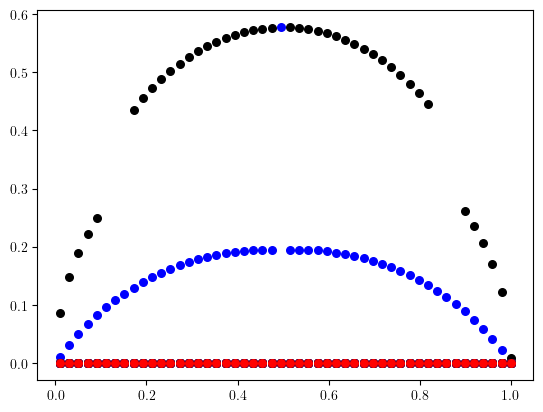

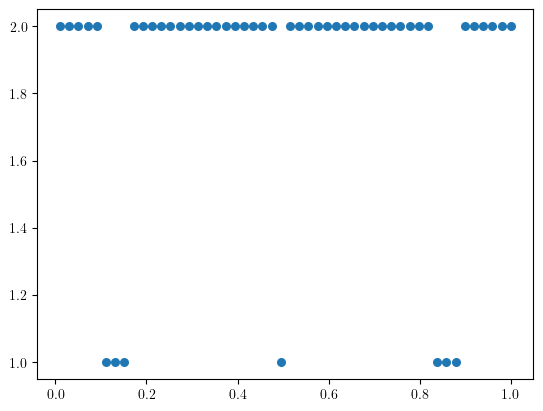

(500, 500)


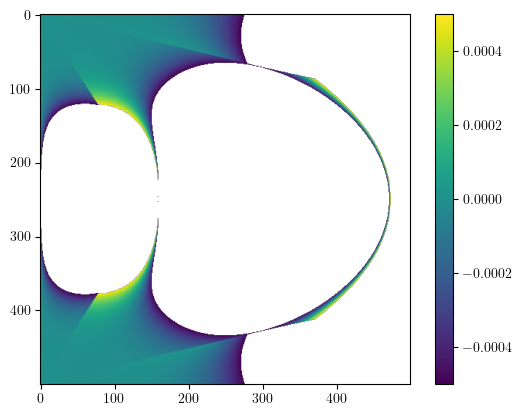

In [8]:
from scipy.optimize import minimize_scalar, minimize, root
from math import isclose
def min_xy(h):
    a=1
    # print(h)
    b = np.linspace(a-max_b(h,a),max_b(h,a),20000000)
    r = np.array([b,h*np.ones(len(b))])
    d = d_aligned(r[0],r[1],a)
    xy = interaction_aligned_dip(r,0,1,100,d)
    min_interaction = np.min(np.abs(xy))
    return min_interaction

def min_xy2d(p):
    a=1
    h = p[0]
    b= p[1]
   
    beta = min(np.sqrt(b**2+h**2),np.sqrt((a-b)**2+h**2))**5/100
    r = np.array([b,h])
    d = d_aligned(r[0],r[1],a)
    xy = interaction_aligned_dip(r,0,1,100,beta,d)
    min_interaction = np.min(np.abs(xy))
    return 0, min_interaction

def min_xy2d_plot(h,b):
    a=1  
    beta = np.min(np.stack((np.sqrt(b**2+h**2),np.sqrt((a-b)**2+h**2))),axis=0)**5/100
    r = np.array([b,h])
    d = d_aligned(r[0],r[1],a)
    # print(d.shape)
    xy = interaction_aligned_dip(r,0,1,1e9,beta,d)
    # print()
    # print(xy.shape,xy)
    # min_interaction = np.min(np.abs(xy),)
    print(xy.shape)
    return np.where(np.abs(xy)<5/1e4,xy,np.nan)
e = 1e-5
bees = np.linspace(0.01,0.9999,50)
# bees = np.linspace(0.4,0.6)
grid = 30
a=1
hmin = np.ones((len(bees),grid))*1000
minima = np.ones_like(hmin)*np.nan
num_sol = np.zeros_like(bees,dtype=np.int16)
for i in range(len(bees)):

    h_grid = np.linspace(1e-6,np.sqrt(1-max(bees[i],a-bees[i])**2),grid)
    for j in range(grid):
        r = root(min_xy2d,x0=(h_grid[j],bees[i]),method="hybr",tol=1e-18)
        ratt = r.x[0]
        trah, moin =  min_xy2d((ratt,bees[i]))
        if 1e-5<ratt and ratt<1 and moin<1e-15:
            new = 1
            for n in range(j):
                if isclose(ratt,hmin[i,n],abs_tol=1e-6):
                    new = 0
            if  new:
                hmin[i,j]=ratt
                minima[i,j] = moin
                num_sol[i] += 1
    # hmin[i,:], minima[i,:]  = sort_eigenvalues(hmin[i,:],minima[i,:]).T
    hmin[i,:] = sorted(hmin[i,:])
    # print(hmin[i,:5])
# minimize(min_xy2d,x0=(0.09,0.1),bounds=np.array([[0.07,0.12],[0.07,0.15]]))
# r = root(min_xy2d,x0=(0.07,0.09),method="hybr",tol=1e-18)
# minimize_scalar(min_xy,bracket=(0.173,1.174),bounds=(0.08,0.1))
# print(minima)
hmin = np.where(hmin==1000,0,hmin)
colors = ['blue','0','red']
fig, ax = plt.subplots(1,1)
# ax.scatter(bees,hmin[:,2],s=30)
for i in range(grid):
    ax.scatter(bees,hmin[:,i],s=30,color=colors[i%3])
plt.show()
fig, ax = plt.subplots(1,1)
ax.scatter(bees,num_sol,s=30)
plt.show()
fig2, ax2 = plt.subplots(1,1)
N = 500
b = np.linspace(0+e,1-e,N)
h = np.linspace(0+e,0.61-e,N)
H, B = np.meshgrid(h,b)

im = ax2.imshow(min_xy2d_plot(H,B),extent=(-0.5, N-0.5, N-0.5, -0.5))
cbar = fig2.colorbar(im,ax=ax2)
plt.show()
# H.shape, min_xy2d_plot(H,B).shape, 

In [9]:


def open_D_mat_sheer(b,h,a,chain_length,interaction,onsite_interaction,*cut):
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    aux_lat = np.zeros((2,2))
    aux_lat[:,0] = -np.array([1,0])*a + b * np.array([1,0]) + h*np.array([0,1])
    aux_lat[:,1] = latticeA.shape[1]*np.array([1,0])*a

    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*a
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*a + b * np.array([1,0])+h*np.array([0,1])
    # for n in range(latticeA.shape[1]):
    #     latticeA[:,n*2] = n*np.array([1,0])*(2+alpha)
        #np.array([frac*a*np.cos(alpha),frac*a*np.sin(alpha)])
    beta = min(np.sqrt(b**2+h**2),np.sqrt((a-b)**2+h**2))**5/100
    d1 = [beta]
    if interaction==interaction_aligned_dip:
        # print('True',d_1(alpha,displace)[2])
        d1 = d1+[d_aligned(b,h,a),]
        # d1 = [np.array([0,0]),]
    

    dmat = np.zeros((2*chain_length,2*chain_length),dtype=complex)
    if not cut:
        cut = max(np.sqrt(b**2+h**2),np.sqrt((a-b)**2+h**2))
    for i in range(4):
        for j in range(4):
            if i <2 and j<2:
                for n in range(latticeA.shape[1]):
                    for m in range(latticeA.shape[1]):
                        if i!=j:
                        # if True:
                            Del_R = latticeB[:,m]-latticeA[:,n]
                            dmat[i*latticeA.shape[1]+n,j*latticeA.shape[1]+n] -= interaction(Del_R,i,j,cut,*d1)
                            # print(n,m,np.linalg.norm(Del_R,),Del_R, interaction(Del_R,i,j,cut))
                        # if i==j and i==1 and n ==0 and m==0:
                        #     Del_R = aux_lat[:,0]-latticeA[:,0]
                            # dmat[i*latticeA.shape[1]+n,j*latticeA.shape[1]+n] = interaction(Del_R,i,j,cut,*d1)
                        if n==m:
                            dmat[i*latticeA.shape[1]+n,j*latticeA.shape[1]+m] += onsite_interaction(i,j)
                        else:
                            Del_R = latticeA[:,m]-latticeA[:,n]
                            dmat[i*latticeA.shape[1]+n,j*latticeA.shape[1]+m] += interaction(Del_R,i,j,cut,*d1)
                            if i!=j:
                            # if True:
                                dmat[i*latticeA.shape[1]+n,j*latticeA.shape[1]+n] -= interaction(Del_R,i,j,cut,*d1)
                        
            if i >=2 and j>=2:
                for n in range(latticeB.shape[1]):
                    for m in range(latticeB.shape[1]):
                        if i!=j:
                        # if True:
                            Del_R = latticeA[:,m]-latticeB[:,n]
                            dmat[2*latticeA.shape[1]+(i-2)*latticeB.shape[1]+n,2*latticeA.shape[1]+(j-2)*latticeB.shape[1]+n] -= interaction(Del_R,i-2,j-2,cut,*d1)

                        # if i==j and i==1 and n ==latticeB.shape[1]-1 and m==latticeB.shape[1]-1:
                        #     Del_R = aux_lat[:,1]-latticeB[:,n]
                        #     dmat[2*latticeA.shape[1]+(i-2)*latticeB.shape[1]+n,2*latticeA.shape[1]+(j-2)*latticeB.shape[1]+n] = interaction(Del_R,i-2,j-2,cut,*d1)
                        
                        if n==m:
                            dmat[2*latticeA.shape[1]+(i-2)*latticeB.shape[1]+n,2*latticeA.shape[1]+(j-2)*latticeB.shape[1]+m] += onsite_interaction(i-2,j-2)
                        else:
                            Del_R = latticeB[:,m]-latticeB[:,n]
                            dmat[2*latticeA.shape[1]+(i-2)*latticeB.shape[1]+n,2*latticeA.shape[1]+(j-2)*latticeB.shape[1]+m] += interaction(Del_R,i-2,j-2,cut,*d1)
                            if i!=j:
                            # if True:
                                dmat[2*latticeA.shape[1]+(i-2)*latticeB.shape[1]+n,2*latticeA.shape[1]+(j-2)*latticeB.shape[1]+n] -= interaction(Del_R,i-2,j-2,cut,*d1)
                        
            if i <2 and j>=2:
                for n in range(latticeA.shape[1]):
                    for m in range(latticeB.shape[1]):
                        Del_R = latticeB[:,m]-latticeA[:,n]
                        dmat[i*latticeA.shape[1]+n,2*latticeA.shape[1]+(j-2)*latticeB.shape[1]+m] = interaction(Del_R,i,j-2,cut,*d1)
                        # print(i*(latticeA.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m)
            if i >=2 and j<2:
                for n in range(latticeB.shape[1]):
                    for m in range(latticeA.shape[1]):
                        Del_R = latticeA[:,m]-latticeB[:,n]
                        dmat[2*latticeA.shape[1]+(i-2)*latticeB.shape[1]+n,j*latticeA.shape[1]+m] = interaction(Del_R,i-2,j,cut,*d1)
                        # print(2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,j*(latticeA.shape[1])+m)
    return dmat, latticeA, latticeB

# b = 0.5
# hmax = np.sqrt((1-0.011)**2-b**2)
# a = 1
# # h = 0.3
# # h = np.linspace(0,hmax,30)
# # bees = np.linspace(a-max_b(h,a),max_b(h,a),30)
# # bees = np.linspace(0.5,0.55,20)
# chain_length = 60
# interaction = interaction_aligned_dip
# # interaction = bare_interaction
# eigenvals = np.zeros((2,len(bees),2*chain_length,2*chain_length+1),dtype=complex)
# # dmat, latticeA, latticeB, lattice_size = open_D_mat(7,bare_interaction_coulomb,bare_interaction_coulomb_onsite,100)
# for j in range(2):
#     fig, ax = plt.subplots(1,1)
#     for i in range(len(bees)):
#         # dmat, latticeA, latticeB, chain_length = open_D_mat(alphas[i],0,chain_length,bare_interaction,no_onsite_interaction)
#         # dmat, latticeA, latticeB = open_D_mat_sheer(bees[i],h,a,chain_length,interaction,dipole_trap_onsite,False)
#         if np.isnan(hmin[i,j]):

#             pass
#         else:
#             dmat, latticeA, latticeB = open_D_mat_sheer(bees[i],hmin[i,j],a,chain_length,interaction,no_onsite_interaction,False)
#             # print(np.max(dmat),dmat.shape)
#             eig, vecs = np.linalg.eig(dmat)
#             eigenvals[j,i,:,0] = eig
#             eigenvals[j,i,:,1:] = vecs.T
#             ax.scatter(bees[i]*np.ones(eig.shape[0]), sorted(np.real(eig)), color='blue', s=10, alpha=0.5)
#     plt.show()

In [10]:
# open lattice consideration zigzag aligned dipole


def open_D_mat_sheer_1Dph(b,h,a,chain_length,interaction,onsite_interaction,phonon_direction,d1):
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*a
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*a + b * np.array([1,0])+h*np.array([0,1])
    # for n in range(latticeA.shape[1]):
    #     latticeA[:,n*2] = n*np.array([1,0])*(2+alpha)
        #np.array([frac*a*np.cos(alpha),frac*a*np.sin(alpha)])
    
    # beta = min(np.sqrt(b**2+h**2),np.sqrt((a-b)**2+h**2))**5/100
    # d1 = [beta]
    # if interaction==interaction_aligned_dip:
    #     # print('True',d_1(alpha,displace)[2])
    #     d1 = d1 + [d_aligned(b,h,a),]
        # d1 = [np.array([0,0]),]
    

    dmat = np.zeros((chain_length,chain_length),dtype=complex)
    cut = np.inf
    # cut = max(np.sqrt(b**2+h**2),np.sqrt((a-b)**2+h**2))
        # print(cut)#[chain_length*10**6]
    for i in range(2):
        for j in range(2):
            if i <1 and j<1:
                for n in range(latticeA.shape[1]):
                    for m in range(latticeA.shape[1]):
                        if i!=j:
                        # if True:
                            Del_R = latticeB[:,m]-latticeA[:,n]
                            dmat[n,n] -= interaction(Del_R,phonon_direction,phonon_direction,d1,cut)
                            # print(n,m,np.linalg.norm(Del_R,),Del_R, interaction(Del_R,i,j,cut,*d1))
                        # if n ==0 and m==0:
                        #     Del_R = aux_lat[:,0]-latticeA[:,n]
                        #     dmat[n,n] = interaction(Del_R,phonon_direction,phonon_direction,cut,*d1)
                        if n==m:
                            dmat[n,m] += onsite_interaction(phonon_direction,phonon_direction)
                        else:
                            Del_R = latticeA[:,m]-latticeA[:,n]
                            dmat[n,m] += interaction(Del_R,phonon_direction,phonon_direction,d1,cut)
                            if i!=j:
                                dmat[n,m] -= interaction(Del_R,phonon_direction,phonon_direction,d1,cut)
                        
            if i >=1 and j>=1:
                for n in range(latticeB.shape[1]):
                    for m in range(latticeB.shape[1]):
                        if i!=j:
                        # if True:
                            Del_R = latticeA[:,m]-latticeB[:,n]
                            dmat[latticeA.shape[1]+n,latticeA.shape[1]+n] -= interaction(Del_R,phonon_direction,phonon_direction,d1,cut)

                        # if n ==latticeB.shape[1]-1 and m==latticeB.shape[1]-1:
                        #     Del_R = aux_lat[:,1]-latticeB[:,n]
                        #     dmat[latticeA.shape[1]+n,latticeA.shape[1]+n] = interaction(Del_R,phonon_direction,phonon_direction,cut,*d1)
                        if n==m:
                            dmat[latticeA.shape[1]+n,latticeA.shape[1]+m] += onsite_interaction(phonon_direction,phonon_direction)
                        else:
                            Del_R = latticeB[:,m]-latticeB[:,n]
                            dmat[latticeA.shape[1]+n,latticeA.shape[1]+m] += interaction(Del_R,phonon_direction,phonon_direction,d1,cut)
                            if i!=j:
                                dmat[latticeA.shape[1]+n,latticeA.shape[1]+n] -= interaction(Del_R,phonon_direction,phonon_direction,d1,cut)
                        
            if i <1 and j>=1:
                for n in range(latticeA.shape[1]):
                    for m in range(latticeB.shape[1]):
                        Del_R = latticeB[:,m]-latticeA[:,n]
                        dmat[n,latticeA.shape[1]+m] = interaction(Del_R,phonon_direction,phonon_direction,d1,cut)
                        # print(i*(latticeA.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m)
            if i >=1 and j<1:
                for n in range(latticeB.shape[1]):
                    for m in range(latticeA.shape[1]):
                        Del_R = latticeA[:,m]-latticeB[:,n]
                        dmat[latticeA.shape[1]+n,m] = interaction(Del_R,phonon_direction,phonon_direction,d1,cut)
                        # print(2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,j*(latticeA.shape[1])+m)
    return dmat, latticeA, latticeB

def open_D_mat_sheer_wrapper(b,h,a,chain_length,interaction,onsite_interaction,d,phonon_direction=2):
    if phonon_direction==2:
        return open_D_mat_sheer(b,h,a,chain_length,interaction,onsite_interaction)
    else:
        return open_D_mat_sheer_1Dph(b,h,a,chain_length,interaction,onsite_interaction,phonon_direction,d)


In [11]:
off = 1.57
amp = 1.95-off
b = amp+off
dmat, latticeA, latticeB = open_D_mat_sheer_wrapper(b,h,a,chain_length,dip_derivative_full,no_onsite_interaction,np.array([np.sqrt(1/3),np.sqrt(2/3)]),0)
np.round(np.real(dmat),2)

NameError: name 'chain_length' is not defined

In [13]:
def photon_Hamiltonian(b,h,a,chain_length,interaction,Delta,d):
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*a
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*a + b * np.array([1,0])+h*np.array([0,1])
    dmat = np.zeros((chain_length,chain_length))
    ind = np.arange(chain_length,dtype=np.int16)
    inter_1 = interaction(latticeB[:,0]-latticeA[:,0],d)
    inter_2 = interaction(latticeB[:,0]-latticeA[:,1],d)
    dmat[ind[:-1:2],ind[1::2]]= inter_1
    dmat[ind[1::2],ind[:-1:2]]= inter_1
    dmat[ind[1:-2:2],ind[2:-1:2]] = inter_2
    dmat[ind[2:-1:2],ind[1:-2:2]] = inter_2
    dmat[ind[::2],ind[::2]] = Delta
    dmat[ind[1::2],ind[1::2]]= -Delta
    # print(inter_1,inter_2,b)
    return dmat

photon_Hamiltonian(0.5,0.2,1,4,dip_dip,1,np.array([1/np.sqrt(3),np.sqrt(2/3)]))

    # for i in range(chain_length//2):
    #     Del_R = latticeB[:,i] - latticeA[:,i]
    #     dmat[2*i,2*i+1] = interaction(Del_R,d)


array([[ 1.        , -7.12846453,  0.        ,  0.        ],
       [-7.12846453, -1.        ,  5.36204038,  0.        ],
       [ 0.        ,  5.36204038,  1.        , -7.12846453],
       [ 0.        ,  0.        , -7.12846453, -1.        ]])

/tmp/ipykernel_4773/2279679337.py:42: ComplexWarning: Casting complex values to real discards the imaginary part
  eigenvalsph[j,i] = sort_eigenvalues(eigsph,vecsph)


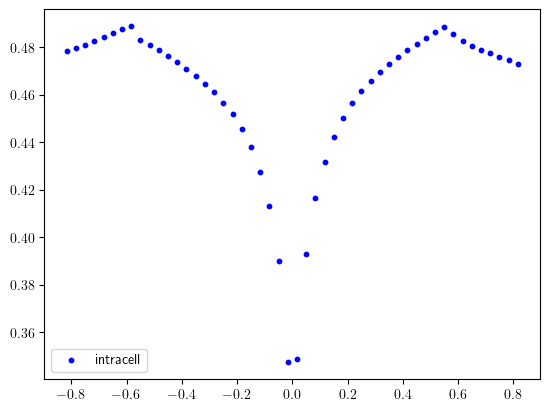

In [14]:
chain_length = 6
h = 0.4
a = 9
# bes = np.linspace(a-max_b(h,a),max_b(h,a),20)-3/8*np.sqrt(2)+1/2
t = np.linspace(0,1,40)
delta = 0*np.sin(2*np.pi*t)/2
def func_Delta(t):
    t1 = np.where(np.abs(t-1/2)>3/8,t,0)
    t2 = np.where(np.abs(t-1/2)<3/8,t,1/8)
    d = (t2-1/2)**2*400-400/64*9
    d += -(np.abs(t1-1/2)-7/16)**2*a*40*16**2+40
    return d
# lamda = np.linspace(-0.6,-0.4,20)
lamda = np.linspace(-np.sqrt(2/3),np.sqrt(2/3))

# d = np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi)])

# delta = (t-1/2)**2*400-400/64*9
# delta= func_Delta(t)
off = a/2#+a/10
amp = a-3-off
bes = np.cos(np.pi*2*t)*amp+off
# bes = np.linspace(0.6,max_b(h,a),20)
# delta = np.ones(chain_length)*30
eigenvals = np.zeros((len(lamda),len(bes),chain_length,chain_length+1))
eigenvalsph = np.zeros((len(lamda),len(bes),chain_length,chain_length+1))
maxi_spin = np.zeros((len(lamda),len(bes)))
maxi_phonon = np.zeros_like(maxi_spin)

fig, ax = plt.subplots(1,1)
for j in range(len(lamda)):
    # print(lamda[j])
    # fig2, ax2 = plt.subplots(1,1)
    # fig3, ax3 = plt.subplots(1,1)
    d = np.array([-np.sqrt(1/3),lamda[j]])
    for i in range(len(bes)):
        dmat = photon_Hamiltonian(bes[i],h,a,chain_length,dip_dip,delta[i],d)
        eigs, vecs = np.linalg.eig(dmat)
        eigenvals[j,i] = sort_eigenvalues(eigs,vecs)
        dmatph, latticeA, latticeB = open_D_mat_sheer_wrapper(bes[i],h,a,chain_length,dip_derivative_full,no_onsite_interaction,d,0)
        eigsph, vecsph = np.linalg.eig(dmatph)
        eigenvalsph[j,i] = sort_eigenvalues(eigsph,vecsph)
        maxi_spin[j,i] = np.max(np.abs(eigs))
        maxi_phonon[j,i] = np.max(np.abs(eigsph))
        # ax3.scatter(t[i]*np.ones(chain_length),eigsph,color="blue")
        # ax2.scatter(t[i]*np.ones(chain_length),eigs,color="blue")
        # ax.scatter(t[i],dmat[0,1],color="blue",s=10)
        # ax.scatter(t[i],dmat[1,2],color='red',s=10)
ax.scatter(lamda,np.max(maxi_spin,axis=1)/np.max(maxi_phonon,axis=1),color="blue",s=10,label="intracell")
# ax.scatter(lamda,np.max(maxi_phonon,axis=1),color='red',s=10,label='intercell')
# ax.scatter(t,delta,color='green',s=10)
ax.legend()
plt.show()



In [ ]:
dmatph, latticeA, latticeB = open_D_mat_sheer_wrapper(2,h,4,chain_length,dip_derivative_full,no_onsite_interaction,d,0)
ei, vec = np.linalg.eig(dmatph)
np.round(np.real(dmatph),2) , np.round(np.real(ei),2)


(array([[ 0.  , -0.01, -0.  , -0.32, -0.  , -0.  ],
        [-0.01,  0.  , -0.01, -0.32, -0.32, -0.  ],
        [-0.  , -0.01,  0.  , -0.  , -0.32, -0.32],
        [-0.32, -0.32, -0.  ,  0.  , -0.01, -0.  ],
        [-0.  , -0.32, -0.32, -0.01,  0.  , -0.01],
        [-0.  , -0.  , -0.32, -0.  , -0.01,  0.  ]]),
 array([-0.6 , -0.4 , -0.13,  0.16,  0.57,  0.4 ]))

/tmp/ipykernel_4773/655883366.py:37: ComplexWarning: Casting complex values to real discards the imaginary part
  eigenvalsph[i] = sort_eigenvalues(eigsph,vecsph)
/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


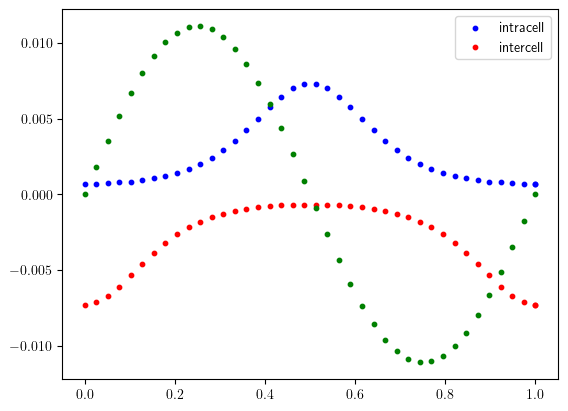

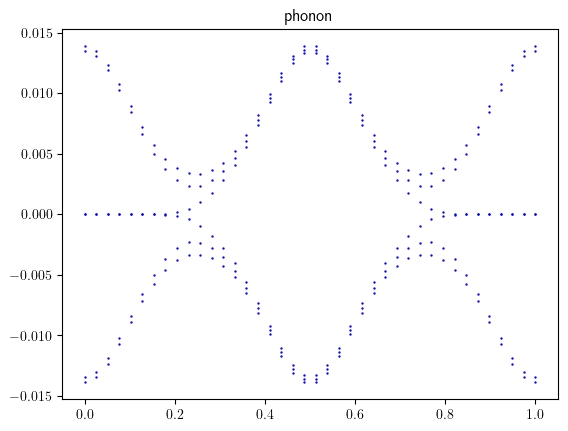

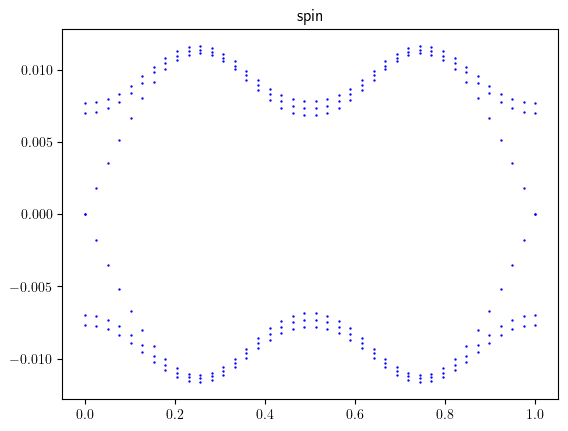

0.9733333333333334

In [15]:
chain_length = 6
h = 0.4
a = 9
# bes = np.linspace(a-max_b(h,a),max_b(h,a),20)-3/8*np.sqrt(2)+1/2
t = np.linspace(0,1,40)
delta = np.sin(2*np.pi*t)/90
def func_Delta(t):
    t1 = np.where(np.abs(t-1/2)>3/8,t,0)
    t2 = np.where(np.abs(t-1/2)<3/8,t,1/8)
    d = (t2-1/2)**2*400-400/64*9
    d += -(np.abs(t1-1/2)-7/16)**2*a*40*16**2+40
    return d
lamda = np.linspace(-np.sqrt(2/3),np.sqrt(2/3))

# d = np.array([0,0])
d = np.array([np.sqrt(1/3),-0.575])
# d = np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi)])

# delta = (t-1/2)**2*400-400/64*9
# delta= func_Delta(t)
off = a/2#+a/10
amp = a-3.2-off
bes = np.cos(np.pi*2*t)*amp+off
# bes = np.linspace(0.6,max_b(h,a),20)
# delta = np.ones(chain_length)*30
eigenvals = np.zeros((len(bes),chain_length,chain_length+1))
eigenvalsph = np.zeros((len(bes),chain_length,chain_length+1))
fig, ax = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
for i in range(len(bes)):
    dmat = photon_Hamiltonian(bes[i],h,a,chain_length,dip_dip,delta[i],d)
    eigs, vecs = np.linalg.eig(dmat)
    eigenvals[i] = sort_eigenvalues(eigs,vecs)
    dmatph, latticeA, latticeB = open_D_mat_sheer_wrapper(bes[i],h,a,chain_length,dip_derivative_full,no_onsite_interaction,d,0)
    eigsph, vecsph = np.linalg.eig(dmatph)
    eigenvalsph[i] = sort_eigenvalues(eigsph,vecsph)
    ax3.scatter(t[i]*np.ones(chain_length),eigsph,color="blue")
    ax2.scatter(t[i]*np.ones(chain_length),eigs,color="blue")
    ax.scatter(t[i],dmat[0,1],color="blue",s=10)
    ax.scatter(t[i],dmat[1,2],color='red',s=10)
ax2.set_title("spin")
ax3.set_title("phonon")
ax.scatter(t[-1],dmat[0,1],color="blue",s=10,label="intracell")
ax.scatter(t[-1],dmat[1,2],color='red',s=10,label='intercell')
ax.scatter(t,delta,color='green',s=10)
ax.legend()
plt.show()

0.8**2+1/3

[-6.25814076e-06  6.25814076e-06]


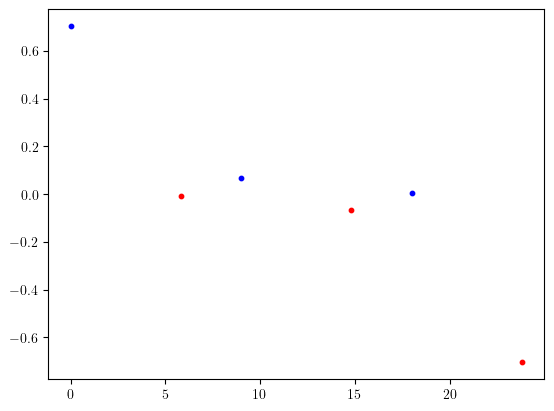

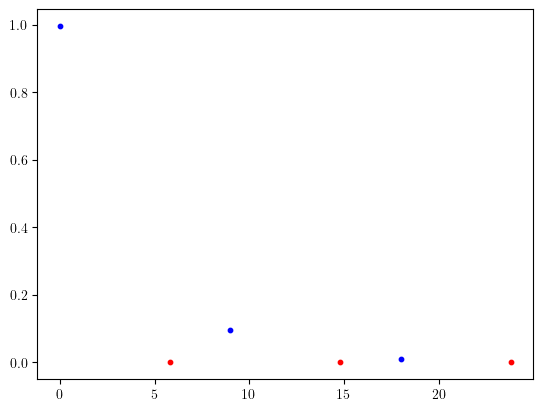

In [16]:
latticeA = np.zeros((2,chain_length//2+chain_length%2))
latticeB = np.zeros((2,chain_length//2))
for n in range(latticeA.shape[1]):
    latticeA[:,n] = n*np.array([1,0])*a
for n in range(latticeB.shape[1]):
    latticeB[:,n] = n*np.array([1,0])*a + bes[0] * np.array([1,0])+h*np.array([0,1])

fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
print(eigenvals[0,:2,0])
ax.scatter(latticeA[0,:],eigenvals[0,0,1::2],color='blue',s=10)
ax.scatter(latticeB[0,:],eigenvals[0,0,2::2],color='red',s=10)
ax2.scatter(latticeA[0,:],1/np.sqrt(2)*(eigenvals[0,1,1::2]+eigenvals[0,0,1::2]),color='blue',s=10)
ax2.scatter(latticeB[0,:],1/np.sqrt(2)*(eigenvals[0,1,2::2]+eigenvals[0,0,2::2]),color='red',s=10)
plt.show()

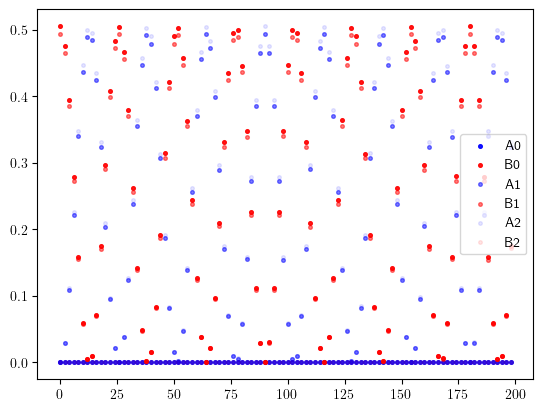

In [ ]:
Ham = photon_Hamiltonian(bes[0],h,a,chain_length,dip_dip,delta[0],np.array([1/np.sqrt(3),np.sqrt(2/3)]))
psi0 = 1/np.sqrt(2)*(eigenvals[0,2,1:]+eigenvals[0,3,1:])
psi0 = psi0.astype(np.complex128)
dt = 2
from scipy.sparse.linalg import expm
U = expm(1j*Ham*dt)
# print(Ham,U)
tsteps = 100
t = np.arange(tsteps)*dt
traj = np.zeros((tsteps,len(psi0)),dtype=complex)
for n in range(tsteps):
    traj[n] = psi0
    psi0 = np.dot(U,psi0)
trajA = traj[:,::2]
trajB = traj[:,1::2]
fig, ax = plt.subplots(1,1)
for i in range(traj.shape[1]//2):
    ax.scatter(t,np.abs(trajA[:,i])**2,color='blue',alpha=0.9-i*0.8/(traj.shape[1]//2-1),s=7,label=f'A{i}')
    ax.scatter(t,np.abs(trajB[:,i])**2,color='red',alpha=0.9-i*0.8/(traj.shape[1]//2-1),s=7,label=f"B{i}")
ax.legend()
plt.show()

In [ ]:
np.round(Ham,2)

array([[ 0.  , -1.03,  0.  ,  0.  ,  0.  ,  0.  ],
       [-1.03, -0.  , 45.93,  0.  ,  0.  ,  0.  ],
       [ 0.  , 45.93,  0.  , -1.03,  0.  ,  0.  ],
       [ 0.  ,  0.  , -1.03, -0.  , 45.93,  0.  ],
       [ 0.  ,  0.  ,  0.  , 45.93,  0.  , -1.03],
       [ 0.  ,  0.  ,  0.  ,  0.  , -1.03, -0.  ]])

In [ ]:


def func_Delta(t):
    t1 = np.where(np.abs(t-1/2)>3/8,t,0)
    t2 = np.where(np.abs(t-1/2)<3/8,t,1/8)
    d = (t2-1/2)**2*400-400/64*9
    d += -(np.abs(t1-1/2)-7/16)**2*a*40*16**2+40
    return d 

def Hamiltonian_spin_only_seriously(Delta,interaction1,interaction2,sigmas_p,sigmas_m,onsite_projectors_spin,chain_length):
    Ham_spin = 0
    for i in range(chain_length//2):
        Ham_spin += Delta * onsite_projectors_spin[2*i] - Delta * onsite_projectors_spin[2*i+1]
        op = interaction1* sigmas_p[i*2]* sigmas_m[i*2+1]
        if  i<chain_length//2-1:
            op2 = interaction2* sigmas_p[i*2+1] * sigmas_m[(i+1)*2]
            Ham_spin += op2 + op2.dag()
        Ham_spin += op+op.dag()
    return Ham_spin


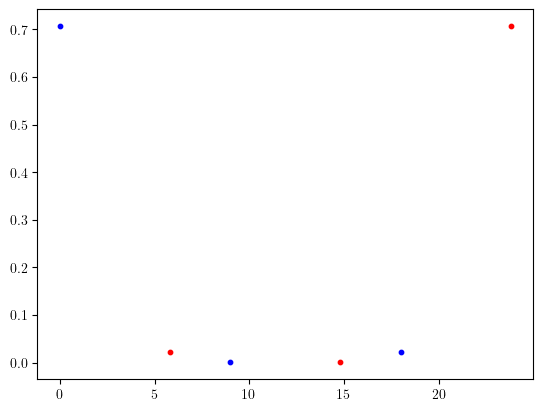

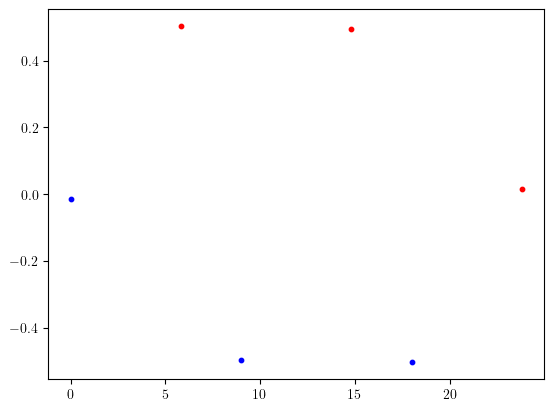

array([[-0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  , -0.01,  0.  ,  0.  ,  0.  ],
       [ 0.  , -0.01, -0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  , -0.01,  0.  ],
       [ 0.  ,  0.  ,  0.  , -0.01, -0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ]])

In [17]:
# off = 1.57
# amp = 1.95-off
# b = amp+off
# dmat, latticeA, latticeB = open_D_mat_sheer_wrapper(b,h,a,chain_length,dip_derivative_full,no_onsite_interaction,np.array([np.sqrt(1/3),np.sqrt(2/3)]),0)
# eigs, vecs = np.linalg.eig(dmat)
# eig_phonon = sort_eigenvalues(eigs,vecs)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
# fig3, ax3 = plt.subplots(1,1)
# ax3.scatter(np.arange(chain_length),eigs,s=10)
# ind = np.arange(chain_length//2,dtype=int)
# print(dmat[ind+chain_length//2,ind],np.max(np.abs(dmat)))
psi0ph = eigenvalsph[0,5,1:]
# psi0ph = 1/np.sqrt(2)*(eigenvalsph[0,0,1:]+ eigenvalsph[0,1,1:])
ax.scatter(latticeA[0,:],eigenvalsph[0,0,1::2],color='blue',s=10)
ax.scatter(latticeB[0,:],eigenvalsph[0,0,2::2],color='red',s=10)
ax2.scatter(latticeA[0,:],psi0ph[0::2],color='blue',s=10)
ax2.scatter(latticeB[0,:],psi0ph[1::2],color='red',s=10)
plt.show()
np.round(np.real(dmat),2)

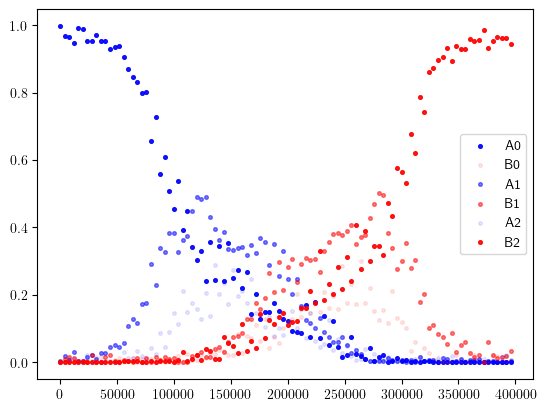

In [ ]:
sigmas_p = []
sigmas_m = []
onsite_projectors_spin = []
for i in range(chain_length):
    op_list = []
    op_list_id = []
    for j in range(chain_length):
        if i == j:
            op_list.append(sigmap())
            op_list_id.append(sigmap()*sigmam())
        else:
            op_list.append(qeye(2))
            op_list_id.append(qeye(2))
    sigmas_p.append(tensor(op_list))
    sigmas_m.append(tensor(op_list).dag())
    onsite_projectors_spin.append(tensor(op_list_id))
dt = 4000
tsteps = 100
t = np.arange(tsteps)*dt
freq = 1/t[-1]
d = np.array([np.sqrt(1/3),0.8])
def Hamiltonian_for_tevol(t):
    delta = np.sin(2*np.pi*t*freq)/90
    off = a/2#+a/10
    amp = a-3.2-off
    b = np.cos(np.pi*2*t*freq)*amp+off
    latticeA = np.array([[0,0],[a,0]])
    latticeB = np.array([b,h])
    inter1 = dip_dip(latticeA[0]-latticeB,d)
    inter2 = dip_dip(latticeA[1]-latticeB,d)
    return Hamiltonian_spin_only_seriously(delta,inter1,inter2,sigmas_p,sigmas_m,onsite_projectors_spin,chain_length)
psi0 = 1/np.sqrt(2)*(eigenvals[0,0,1:]+eigenvals[0,1,1:])
# psi0 = eigenvals[0,0,1:]
psi0 = psi0.astype(np.complex128)
down = tensor([basis(2,1) for i in range(chain_length)])
psi0q = 0
for i in range(chain_length):
    psi0q += sigmas_p[i]* down*psi0[i]
# Hamiltonian_for_tevol(0)

traj = sesolve(Hamiltonian_for_tevol,psi0q,t,e_ops=onsite_projectors_spin)
fig, ax = plt.subplots(1,1)
for i in range(chain_length//2):
    ax.scatter(t,traj.expect[2*i],color='blue',alpha=0.9-i*0.8/(chain_length//2-1),s=7,label=f'A{i}')
    ax.scatter(t,traj.expect[2*i+1],color='red',alpha=0.1+i*0.8/(chain_length//2-1),s=7,label=f"B{i}")
ax.legend()
plt.show()
# traj = sesolve(Hamiltonian_for_tevol,)

In [ ]:
from qutip import tensor, basis, destroy, create, qeye, sesolve, sigmap, sigmam


def Hamiltonian_1Dph(Delta,b,h,a,phonon_direction,d):
    latticeA = np.array([[0,0],[a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeA[0]-latticeB
    dist2 = latticeA[1]-latticeB
    inter1 = dip_dip(dist1,d)
    inter2 = dip_dip(dist2,d)
    inter_ph1 = dip_derivative_full(dist1,phonon_direction,phonon_direction,d)
    inter_ph2 = dip_derivative_full(dist2,phonon_direction,phonon_direction,d)
    
    
    return Hamiltonian_spin_only(Delta,inter1,inter2) + Hamiltonian_spin_phonon(inter_ph1,inter_ph2)


def Hamiltonian_spin_only(Delta,interaction1,interaction2):
    Ham_spin = 0
    for i in range(chain_length//2):
        Ham_spin += Delta * tensor(onsite_projectors_spin[2*i],unity_phonon) - Delta * tensor(onsite_projectors_spin[2*i+1],unity_phonon)
        op = interaction1* tensor(sigmas_p[i*2],unity_phonon)* tensor(sigmas_m[i*2+1],unity_phonon)
        if  i<chain_length//2-1:
            op2 = interaction2* tensor(sigmas_p[i*2+1],unity_phonon) * tensor(sigmas_m[(i+1)*2],unity_phonon)
            Ham_spin += op2 + op2.dag()
        Ham_spin += op+op.dag()
    return Ham_spin

def Hamiltonian_spin_phonon(interaction1,interaction2):
    Ham_ps= 0
    for i in range(chain_length//2):
        op_ph = interaction1 * (annihilation_phonon[2*i].dag()*annihilation_phonon[2*i+1] + annihilation_phonon[2*i+1].dag()*annihilation_phonon[2*i]-annihilation_phonon[2*i].dag()*annihilation_phonon[2*i]-annihilation_phonon[2*i+1].dag()*annihilation_phonon[2*i+1])
        Ham_ps += tensor(sigmas_p[i*2]*sigmas_m[i*2+1],op_ph)
        if i<chain_length//2-1:
            op_ph2 = interaction2 * (annihilation_phonon[2*i+1].dag()*annihilation_phonon[2*(i+1)] + annihilation_phonon[2*(i+1)].dag()*annihilation_phonon[2*i+1]-annihilation_phonon[2*i+1].dag()*annihilation_phonon[2*i+1]-annihilation_phonon[2*(i+1)].dag()*annihilation_phonon[2*(i+1)])
            Ham_ps += tensor(sigmas_p[i*2+1]*sigmas_m[2*(i+1)],op_ph2)
    return Ham_ps + Ham_ps.dag()
         




10.1%. Run time:   8.67s. Est. time left: 00:00:01:17
20.2%. Run time:  13.73s. Est. time left: 00:00:00:54
30.3%. Run time:  16.12s. Est. time left: 00:00:00:37
40.4%. Run time:  19.10s. Est. time left: 00:00:00:28
50.5%. Run time:  25.54s. Est. time left: 00:00:00:25
60.6%. Run time:  32.77s. Est. time left: 00:00:00:21
70.7%. Run time:  36.87s. Est. time left: 00:00:00:15
80.8%. Run time:  38.98s. Est. time left: 00:00:00:09
90.9%. Run time:  42.00s. Est. time left: 00:00:00:04
100.0%. Run time:  47.61s. Est. time left: 00:00:00:00
Total run time:  47.61s


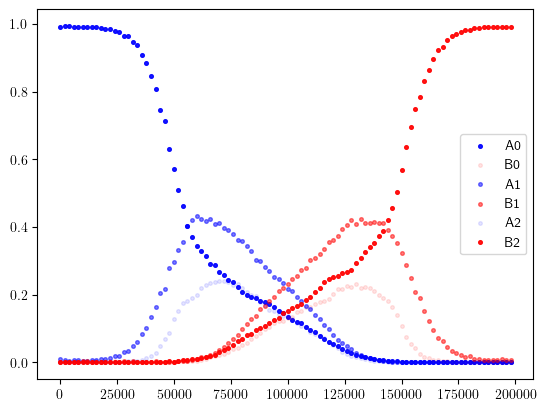

In [ ]:
chain_length = 6
boson_number = 2
annihilation_phonon = []
for i in range(chain_length):
    op_list = []
    for j in range(chain_length):
        if i == j:
            op_list.append(destroy(boson_number))
        else:
            op_list.append(qeye(boson_number))
    annihilation_phonon.append(tensor(op_list))
unity_phonon = tensor([qeye(boson_number) for i in range(chain_length)])
sigmas_p = []
sigmas_m = []
onsite_projectors_spin = []
projectors_eval = []
for i in range(chain_length):
    op_list = []
    op_list_id = []
    for j in range(chain_length):
        if i == j:
            op_list.append(sigmap())
            op_list_id.append(sigmap()*sigmam())
        else:
            op_list.append(qeye(2))
            op_list_id.append(qeye(2))
    sigmas_p.append(tensor(op_list))
    sigmas_m.append(tensor(op_list).dag())
    onsite_projectors_spin.append(tensor(op_list_id))
    projectors_eval.append(tensor(onsite_projectors_spin[-1],unity_phonon))

dt = 2000
tsteps = 100
t = np.arange(tsteps)*dt
freq = 1/t[-1]
d = np.array([np.sqrt(1/3),0.8])

def Hamiltonian_spph_for_tevol(t):
    delta = np.sin(2*np.pi*t*freq)/90
    off = a/2#+a/10
    amp = a-3-off
    b = np.cos(np.pi*2*t*freq)*amp+off
    return Hamiltonian_1Dph(delta,b,h,a,0,d)
psi0 = 1/np.sqrt(2)*(eigenvals[0,0,1:]+eigenvals[0,1,1:])
psi0 = psi0.astype(np.complex128)
down = tensor([basis(2,1) for i in range(chain_length)])
psi0q = 0
for i in range(chain_length):
    psi0q += sigmas_p[i]* down*psi0[i]
# Hamiltonian_spph_for_tevol(0)

phonon0 = tensor([basis(boson_number,0) for i in range(chain_length)])

# psi0ph = 1/np.sqrt(2)*(eigenvalsph[0,0,1:]+eigenvalsph[0,1,1:])
eig_generator_ph = 0
for i in range(chain_length):
    eig_generator_ph += psi0ph[i] * annihilation_phonon[i].dag()

psi0q = tensor(psi0q,eig_generator_ph*phonon0)
psi0q.norm()
traj = sesolve(Hamiltonian_spph_for_tevol,psi0q,t,e_ops=projectors_eval,options={"progress_bar":True,"store_final_state":True})
fig, ax = plt.subplots(1,1)
for i in range(chain_length//2):
    ax.scatter(t,traj.expect[2*i],color='blue',alpha=0.9-i*0.8/(chain_length//2-1),s=7,label=f'A{i}')
    ax.scatter(t,traj.expect[2*i+1],color='red',alpha=0.1+i*0.8/(chain_length//2-1),s=7,label=f"B{i}")
ax.legend()
plt.show()
    

In [ ]:
from qutip import tensor, basis, destroy, create, qeye, sesolve
chain_length = 8
boson_number = 5
p_index= 30
t_numb = 100
t_end = 60
interaction = interaction_aligned_dip
dmat, latticeA, latticeB = open_D_mat_sheer_wrapper(bees[p_index],hmin[p_index,0],a,chain_length,interaction,no_onsite_interaction,phonon_direction=0)
annihilation = []
for i in range(dmat.shape[0]):
    op_list = []
    for j in range(dmat.shape[0]):
        if i == j:
            op_list.append(destroy(boson_number))
        else:
            op_list.append(qeye(boson_number))
    annihilation.append(tensor(op_list))

Hamiltonian = 0

dmat = np.real(dmat)
for i in range(dmat.shape[0]):
    for j in range(dmat.shape[1]):
        Hamiltonian += dmat[i,j]*annihilation[i].dag()*annihilation[j]
Hamiltonian = Hamiltonian.tidyup(1e-12)

psi0 = []
ex0 = 0
for i in range(dmat.shape[0]):
    if i==ex0:
        psi0.append(basis(boson_number,2))
    else:
        psi0.append(basis(boson_number,0))
t_points = np.linspace(0,t_end,t_numb)

# Hamiltonian.datatensor(psi0)
traj = sesolve(Hamiltonian,tensor(psi0) , t_points,e_ops = [annihilation[i].dag()*annihilation[i] for i in range(dmat.shape[0])],options={"progress_bar":True,"store_final_state":True})

10.1%. Run time:   0.44s. Est. time left: 00:00:00:03
20.2%. Run time:   0.73s. Est. time left: 00:00:00:02
30.3%. Run time:   0.94s. Est. time left: 00:00:00:02
40.4%. Run time:   1.14s. Est. time left: 00:00:00:01
50.5%. Run time:   1.33s. Est. time left: 00:00:00:01
60.6%. Run time:   1.53s. Est. time left: 00:00:00:00
70.7%. Run time:   1.74s. Est. time left: 00:00:00:00
80.8%. Run time:   1.96s. Est. time left: 00:00:00:00
90.9%. Run time:   2.16s. Est. time left: 00:00:00:00
100.0%. Run time:   2.35s. Est. time left: 00:00:00:00
Total run time:   2.36s


In [ ]:
from scipy.sparse import *
def scipy_annhiliation(boson_number):
    off_diag = np.sqrt(np.arange(1,boson_number))
    indices = np.zeros((2,boson_number-1),dtype = int)
    for i in range(boson_number-1):
        indices[0,i]= i
        indices[1,i] = i+1
    return coo_matrix((off_diag,indices),shape=(boson_number,boson_number)).tocsr()

def unity(boson_number):
    return csr_matrix(np.identity(boson_number))

def tensor_scipy(A,B):
    
    dataA = np.array(A.tocoo().data)
    dataB = np.array(B.tocoo().data)
    indicesA = np.array(A.tocoo().coords)
    indicesB = np.array(B.tocoo().coords)
    # print(indicesB)
    new_data = np.zeros(len(dataA)*len(dataB),dtype=A.dtype)
    new_indices = np.zeros((2,len(dataA)*len(dataB)),dtype=int)
    for i in range(len(dataA)):
        new_indices[0,i*len(dataB):(i+1)*len(dataB)] = indicesB[0,:]+B.shape[0]*indicesA[0,i]
        new_indices[1,i*len(dataB):(i+1)*len(dataB)] = indicesB[1,:]+B.shape[0]*indicesA[1,i]
        new_data[i*len(dataB):(i+1)*len(dataB)] = dataA[i]*dataB
    # print(new_indices)
    # print(new_data)
    return coo_matrix((new_data,new_indices),shape=[A.shape[0]*B.shape[0],A.shape[1]*B.shape[1]]).tocsr()

def tensor_scipy_list(list):
    res = list[0]
    for i in range(1,len(list)):
        res = tensor_scipy(res,list[i])
    return res

In [ ]:
chain_length = 8
boson_number = 5
p_index= 30
t_numb = 100
t_end = 60


dmat, latticeA, latticeB = open_D_mat_sheer_wrapper(bees[p_index],hmin[p_index,0],a,chain_length,interaction,no_onsite_interaction,phonon_direction=0)
a_op = scipy_annhiliation(boson_number)
identity = unity(boson_number)
annihilation = []
for i in range(dmat.shape[0]):
    op_list = []
    for j in range(dmat.shape[0]):
        if i == j:
            op_list.append(a_op)
        else:
            op_list.append(identity)
    annihilation.append(tensor_scipy_list(op_list))

Hamiltonian = 0

dmat = np.real(dmat)
for i in range(dmat.shape[0]):
    for j in range(dmat.shape[1]):
        Hamiltonian += dmat[i,j]*annihilation[i].transpose().conj()*annihilation[j]
# Hamiltonian = Hamiltonian.tidyup(1e-12)
from scipy.sparse.linalg import eigs, expm, expm_multiply

traj_scipy = np.zeros((dmat.shape[0],t_numb),dtype=complex)
zeros = np.zeros((boson_number,1))
zeros[0,0] =1 
e1 = np.zeros((boson_number,1))
e1[2,0] = 1
zeros = csr_matrix(zeros)
e1 = csr_matrix(e1)
psi0 = []
ex0 = 0
for i in range(dmat.shape[0]):
    if i==ex0:
        psi0.append(e1)
    else:
        psi0.append(zeros)
psi0 = tensor_scipy_list(psi0)
psi_t = expm_multiply((-1j*Hamiltonian),psi0,start=0,stop=t_end,num= t_numb)
np.all(psi0.toarray()==0), np.shape(psi_t), psi0.toarray().shape
for i in range(dmat.shape[0]):
    n_op = annihilation[i].transpose().conj().dot(annihilation[i])
    for ti in range(t_numb):
        # traj_scipy[i,ti] = np.tensordot(np.tensordot(psi_t[ti,:,0].transpose().conj(),n_op.toarray(),axes=1),psi_t[ti,:,0],axes=1)
        traj_scipy[i,ti] = csr_matrix(psi_t[ti,:,0]).conj().dot(n_op).dot(psi_t[ti,:,0])[0]
# # Hamiltonian.datatensor(psi0)
# traj = sesolve(Hamiltonian,tensor([qeye(boson_number) for i in range(dmat.shape[0])]) , t_points,e_ops = [annihilation[i].dag()*annihilation[i] for i in range(dmat.shape[0])],options={"progress_bar":True,"store_final_state":True})

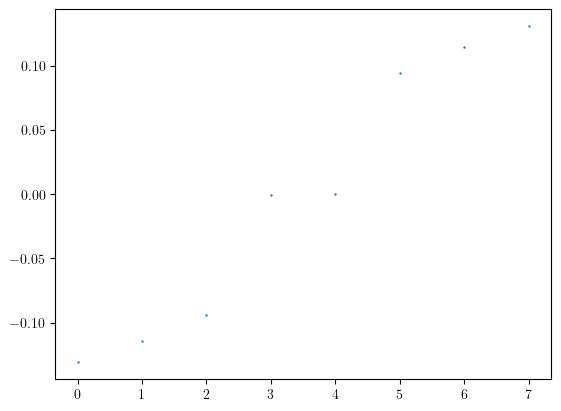

0.0	0.0	0.0	0.0	0.0	0.0	0.0	
0.0	0.0	0.0	0.0	0.0	0.0	0.0	
0.0	0.0	0.0	0.0	0.0	0.0	0.0	
0.0	0.0	0.0	0.0	0.0	0.0	0.0	
0.0	0.0	0.0	0.0	0.0	0.0	0.0	
0.0	0.0	0.0	0.0	0.0	0.0	0.0	
0.0	0.0	0.0	0.0	0.0	0.0	0.0	
0.0	0.0	0.0	0.0	0.0	0.0	0.0	


(8, np.float64(0.0007297830163956206))

In [ ]:
eig, vecs = np.linalg.eig(dmat)
eigenvals = np.array(sorted(np.real(eig)))
eigenspaces = [[eigenvals[0]]]
for i in range(1,dmat.shape[0]):
    if np.abs(eigenvals[i]-eigenvals[i-1])>1e-8:
        eigenspaces.append([eigenvals[i]])
    else:
        eigenspaces[-1].append(eigenvals[i])
fig, ax = plt.subplots(1,1)
ax.scatter(np.arange(len(eigenvals)),eigenvals)
plt.show()
for i in range(len(eigenvals)):
    for j in range(len(eigenvals)):
        if i!=j:
            print(np.where(np.abs(np.dot(vecs[:,i].conj(),vecs[:,j]))>1e-5,np.dot(vecs[:,i].conj(),vecs[:,j]),0),end="\t")
    print()
len(eigenspaces), np.min(np.abs(eigenvals[1:]-eigenvals[:-1]))


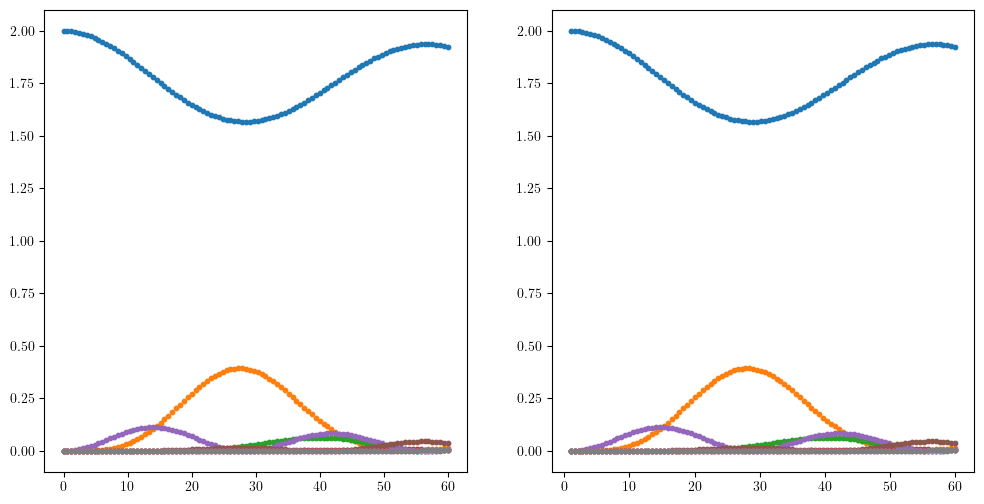

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(12,6))
for i in range(len(traj.expect)):
    ax[0].scatter(t_points,traj.expect[i],s=10,label=f"site {i}")
for i in range(dmat.shape[0]):
    ax[1].scatter(np.linspace(1,t_end,t_numb),np.real(traj_scipy[i,:]),s=10)
# ax.legend()
plt.show()